In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
class FuzzyStartupPredictor:
    def __init__(self):
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        self.mamdani_system = None
        self.sugeno_system = None
        
    def load_and_preprocess_data(self, file_path):
        """Load dan preprocessing data"""
        print("📊 Loading dan preprocessing data...")
        
        # Load data
        self.df = pd.read_csv(file_path)
        print(f"Dataset shape: {self.df.shape}")
        print(f"Columns: {list(self.df.columns)}")
        
        # Display basic info
        print("\n📈 Dataset Info:")
        print(self.df.info())
        print("\n📊 Dataset Description:")
        print(self.df.describe())
        
        # Handle missing values
        self.df = self.df.dropna()
        
        # Prepare features and target
        feature_cols = ['Startup_Age', 'Funding_Amount', 'Number_of_Founders', 'Employees_Count']
        
        # Check if columns exist
        available_cols = [col for col in feature_cols if col in self.df.columns]
        if len(available_cols) < 4:
            print(f"⚠️  Tidak semua kolom tersedia. Menggunakan kolom yang ada: {available_cols}")
            # Use first 4 numeric columns if original columns not found
            numeric_cols = self.df.select_dtypes(include=[np.number]).columns.tolist()
            if len(numeric_cols) >= 4:
                feature_cols = numeric_cols[:4]
                print(f"🔄 Menggunakan kolom numerik: {feature_cols}")
            else:
                raise ValueError("Tidak cukup kolom numerik untuk analisis")
        
        self.X = self.df[feature_cols]
        
        # Handle target variable
        target_col = 'Startup_Status'
        if target_col not in self.df.columns:
            # Use last column as target
            target_col = self.df.columns[-1]
            print(f"🎯 Menggunakan kolom '{target_col}' sebagai target")
        
        self.y = self.df[target_col]
        
        # Encode target if categorical
        if self.y.dtype == 'object':
            self.y_encoded = self.label_encoder.fit_transform(self.y)
            self.target_classes = self.label_encoder.classes_
        else:
            self.y_encoded = self.y
            self.target_classes = sorted(self.y.unique())
        
        # Split data
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y_encoded, test_size=0.3, random_state=42, stratify=self.y_encoded
        )
        
        # Scale features
        self.X_train_scaled = self.scaler.fit_transform(self.X_train)
        self.X_test_scaled = self.scaler.transform(self.X_test)
        
        print(f"✅ Data preprocessing selesai!")
        print(f"Training set: {self.X_train.shape[0]} samples")
        print(f"Test set: {self.X_test.shape[0]} samples")
        print(f"Target classes: {self.target_classes}")
        
        return self.df
    
    def visualize_data_distribution(self):
        """Visualisasi distribusi data"""
        print("\n📊 Membuat visualisasi distribusi data...")
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('Distribusi Fitur Dataset Startup', fontsize=16, fontweight='bold')
        
        # Plot distribusi setiap fitur
        for i, col in enumerate(self.X.columns):
            row = i // 3
            col_idx = i % 3
            
            axes[row, col_idx].hist(self.X[col], bins=30, alpha=0.7, color=sns.color_palette()[i])
            axes[row, col_idx].set_title(f'Distribusi {col}', fontweight='bold')
            axes[row, col_idx].set_xlabel(col)
            axes[row, col_idx].set_ylabel('Frekuensi')
            axes[row, col_idx].grid(True, alpha=0.3)
        
        # Plot distribusi target
        if len(self.X.columns) < 6:
            row = 1
            col_idx = len(self.X.columns) % 3
            
            target_counts = pd.Series(self.y_encoded).value_counts().sort_index()
            axes[row, col_idx].bar(range(len(target_counts)), target_counts.values, 
                                  color=sns.color_palette()[len(self.X.columns)])
            axes[row, col_idx].set_title('Distribusi Target (Startup Status)', fontweight='bold')
            axes[row, col_idx].set_xlabel('Status Class')
            axes[row, col_idx].set_ylabel('Jumlah')
            axes[row, col_idx].set_xticks(range(len(self.target_classes)))
            axes[row, col_idx].set_xticklabels(self.target_classes)
            axes[row, col_idx].grid(True, alpha=0.3)
        
        # Hide unused subplots
        for i in range(len(self.X.columns) + 1, 6):
            row = i // 3
            col_idx = i % 3
            axes[row, col_idx].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        
        # Correlation heatmap
        plt.figure(figsize=(10, 8))
        correlation_data = self.X.copy()
        correlation_data['Target'] = self.y_encoded
        corr_matrix = correlation_data.corr()
        
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
                   square=True, linewidths=0.5)
        plt.title('Matriks Korelasi Fitur dengan Target', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    def setup_fuzzy_systems(self):
        """Setup sistem fuzzy Mamdani dan Sugeno"""
        print("\n🔧 Setting up sistem fuzzy...")
        
        # Normalisasi range untuk fuzzy variables
        feature_ranges = {}
        for i, col in enumerate(self.X.columns):
            min_val = float(self.X[col].min())
            max_val = float(self.X[col].max())
            feature_ranges[col] = (min_val, max_val)
        
        # Setup Mamdani System
        print("🔹 Setting up Mamdani system...")
        self.setup_mamdani_system(feature_ranges)
        
        # Setup Sugeno System  
        print("🔹 Setting up Sugeno system...")
        self.setup_sugeno_system(feature_ranges)
        
        print("✅ Fuzzy systems setup completed!")
    
    def setup_mamdani_system(self, feature_ranges):
        """Setup Mamdani fuzzy system"""
        # Create input variables
        inputs = {}
        for col, (min_val, max_val) in feature_ranges.items():
            inputs[col] = ctrl.Antecedent(np.linspace(min_val, max_val, 100), col)
            
            # Define membership functions
            inputs[col]['low'] = fuzz.trimf(inputs[col].universe, 
                                          [min_val, min_val, (min_val + max_val) / 2])
            inputs[col]['medium'] = fuzz.trimf(inputs[col].universe, 
                                             [min_val, (min_val + max_val) / 2, max_val])
            inputs[col]['high'] = fuzz.trimf(inputs[col].universe, 
                                           [(min_val + max_val) / 2, max_val, max_val])
        
        # Create output variable
        output = ctrl.Consequent(np.linspace(0, len(self.target_classes)-1, 100), 'startup_status')
        
        # Define output membership functions
        n_classes = len(self.target_classes)
        if n_classes == 2:
            output['fail'] = fuzz.trimf(output.universe, [0, 0, 0.5])
            output['success'] = fuzz.trimf(output.universe, [0.5, 1, 1])
        else:
            for i in range(n_classes):
                class_name = f'class_{i}'
                if i == 0:
                    output[class_name] = fuzz.trimf(output.universe, [i, i, i+0.5])
                elif i == n_classes - 1:
                    output[class_name] = fuzz.trimf(output.universe, [i-0.5, i, i])
                else:
                    output[class_name] = fuzz.trimf(output.universe, [i-0.5, i, i+0.5])
        
        # Create rules (simplified rule base)
        rules = []
        input_vars = list(inputs.values())
        
        # Rule 1: If most inputs are low, then failure
        if n_classes == 2:
            rules.append(ctrl.Rule(input_vars[0]['low'] & input_vars[1]['low'], output['fail']))
            rules.append(ctrl.Rule(input_vars[0]['high'] & input_vars[1]['high'], output['success']))
            rules.append(ctrl.Rule(input_vars[2]['low'] & input_vars[3]['low'], output['fail']))
            rules.append(ctrl.Rule(input_vars[2]['high'] & input_vars[3]['high'], output['success']))
        
        # Create control system
        self.mamdani_system = ctrl.ControlSystem(rules)
        self.mamdani_sim = ctrl.ControlSystemSimulation(self.mamdani_system)
    
    def setup_sugeno_system(self, feature_ranges):
        """Setup Sugeno fuzzy system (simplified implementation)"""
        # For Sugeno, we'll use a simplified approach with linear output functions
        self.sugeno_weights = {}
        
        # Initialize weights for each input variable
        for col in feature_ranges.keys():
            self.sugeno_weights[col] = np.random.uniform(-1, 1, size=3)  # 3 membership functions
        
        # Bias terms
        self.sugeno_bias = np.random.uniform(-1, 1, size=len(self.target_classes))
    
    def predict_mamdani(self, X):
        """Prediksi menggunakan sistem Mamdani"""
        predictions = []
        
        for i in range(len(X)):
            try:
                # Set input values
                for j, col in enumerate(self.X.columns):
                    self.mamdani_sim.input[col] = X[i, j]
                
                # Compute output
                self.mamdani_sim.compute()
                
                # Get output value
                output_val = self.mamdani_sim.output['startup_status']
                
                # Convert to class prediction
                pred_class = int(round(output_val))
                pred_class = max(0, min(pred_class, len(self.target_classes)-1))
                predictions.append(pred_class)
                
            except Exception as e:
                # Fallback prediction
                predictions.append(0)
        
        return np.array(predictions)
    
    def predict_sugeno(self, X):
        """Prediksi menggunakan sistem Sugeno"""
        predictions = []
        
        for i in range(len(X)):
            # Calculate membership degrees for each input
            memberships = {}
            
            for j, col in enumerate(self.X.columns):
                val = X[i, j]
                # Simple triangular membership functions
                min_val = self.X[col].min()
                max_val = self.X[col].max()
                
                # Low membership
                if val <= (min_val + max_val) / 2:
                    low_mem = 1 - 2 * (val - min_val) / (max_val - min_val)
                else:
                    low_mem = 0
                
                # High membership  
                if val >= (min_val + max_val) / 2:
                    high_mem = 2 * (val - min_val) / (max_val - min_val) - 1
                else:
                    high_mem = 0
                
                # Medium membership
                if val <= (min_val + max_val) / 2:
                    medium_mem = 2 * (val - min_val) / (max_val - min_val)
                else:
                    medium_mem = 2 - 2 * (val - min_val) / (max_val - min_val)
                
                memberships[col] = [max(0, low_mem), max(0, medium_mem), max(0, high_mem)]
            
            # Aggregate using weighted sum
            output_sum = 0
            weight_sum = 0
            
            for col, mems in memberships.items():
                for k, mem in enumerate(mems):
                    if mem > 0:
                        weight = mem * self.sugeno_weights[col][k]
                        output_sum += weight
                        weight_sum += mem
            
            if weight_sum > 0:
                final_output = output_sum / weight_sum + np.mean(self.sugeno_bias)
            else:
                final_output = np.mean(self.sugeno_bias)
            
            # Convert to class prediction
            pred_class = int(round(abs(final_output) % len(self.target_classes)))
            predictions.append(pred_class)
        
        return np.array(predictions)
    
    def evaluate_systems(self):
        """Evaluasi kedua sistem fuzzy"""
        print("\n🔍 Evaluating fuzzy systems...")
        
        # Predict with both systems
        print("🔹 Predicting with Mamdani system...")
        mamdani_pred = self.predict_mamdani(self.X_test_scaled)
        
        print("🔹 Predicting with Sugeno system...")
        sugeno_pred = self.predict_sugeno(self.X_test_scaled)
        
        # Calculate accuracies
        mamdani_acc = accuracy_score(self.y_test, mamdani_pred)
        sugeno_acc = accuracy_score(self.y_test, sugeno_pred)
        
        print(f"\n📊 HASIL EVALUASI:")
        print(f"Akurasi Mamdani: {mamdani_acc:.4f} ({mamdani_acc*100:.2f}%)")
        print(f"Akurasi Sugeno:  {sugeno_acc:.4f} ({sugeno_acc*100:.2f}%)")
        
        # Visualize confusion matrices
        self.plot_confusion_matrices(mamdani_pred, sugeno_pred)
        
        return mamdani_acc, sugeno_acc, mamdani_pred, sugeno_pred
    
    def plot_confusion_matrices(self, mamdani_pred, sugeno_pred):
        """Plot confusion matrices untuk kedua sistem"""
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        # Mamdani confusion matrix
        cm_mamdani = confusion_matrix(self.y_test, mamdani_pred)
        sns.heatmap(cm_mamdani, annot=True, fmt='d', cmap='Blues', ax=axes[0])
        axes[0].set_title('Confusion Matrix - Mamdani System', fontweight='bold')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')
        
        # Sugeno confusion matrix
        cm_sugeno = confusion_matrix(self.y_test, sugeno_pred)
        sns.heatmap(cm_sugeno, annot=True, fmt='d', cmap='Reds', ax=axes[1])
        axes[1].set_title('Confusion Matrix - Sugeno System', fontweight='bold')
        axes[1].set_xlabel('Predicted')
        axes[1].set_ylabel('Actual')
        
        plt.tight_layout()
        plt.show()
    
    def analyze_feature_importance(self):
        """Analisis pentingnya fitur"""
        print("\n🔍 Analyzing feature importance...")
        
        # Calculate correlations
        correlations = {}
        for col in self.X.columns:
            corr = np.corrcoef(self.X[col], self.y_encoded)[0, 1]
            correlations[col] = abs(corr)  # Use absolute correlation
        
        # Sort by correlation
        sorted_corr = dict(sorted(correlations.items(), key=lambda x: x[1], reverse=True))
        
        print("\n📊 ANALISIS PENTINGNYA FITUR")
        print("="*50)
        print("Korelasi fitur dengan Startup_Status (diurutkan):")
        for feature, corr in sorted_corr.items():
            print(f"  {feature}: {corr:.3f}")
        
        # Visualize feature importance
        plt.figure(figsize=(10, 6))
        features = list(sorted_corr.keys())
        importances = list(sorted_corr.values())
        
        bars = plt.bar(features, importances, color=sns.color_palette("viridis", len(features)))
        plt.title('Pentingnya Fitur berdasarkan Korelasi dengan Target', fontweight='bold')
        plt.xlabel('Fitur')
        plt.ylabel('Korelasi Absolut')
        plt.xticks(rotation=45)
        
        # Add value labels on bars
        for bar, importance in zip(bars, importances):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{importance:.3f}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.grid(True, alpha=0.3)
        plt.show()
        
        return sorted_corr
    
    def generate_conclusion(self, mamdani_acc, sugeno_acc, feature_importance):
        """Generate kesimpulan analisis"""
        print("\n" + "="*70)
        print("KESIMPULAN")
        print("="*70)
        print(f"1. Akurasi Sistem Mamdani: {mamdani_acc:.4f} ({mamdani_acc*100:.2f}%)")
        print(f"2. Akurasi Sistem Sugeno:  {sugeno_acc:.4f} ({sugeno_acc*100:.2f}%)")
        
        if abs(mamdani_acc - sugeno_acc) < 0.01:
            print("3. Kedua sistem memiliki performa yang hampir sama")
        elif mamdani_acc > sugeno_acc:
            print("3. Sistem Mamdani menunjukkan performa yang lebih baik")
        else:
            print("3. Sistem Sugeno menunjukkan performa yang lebih baik")
        
        # Feature importance insights
        most_important = list(feature_importance.keys())[0]
        print(f"4. Fitur paling penting: {most_important} (korelasi: {feature_importance[most_important]:.3f})")
        
        least_important = list(feature_importance.keys())[-1]
        print(f"5. Fitur paling lemah: {least_important} (korelasi: {feature_importance[least_important]:.3f})")
        
        print("="*70)


# Instructions untuk menjalankan:
print("""
📋 CARA PENGGUNAAN:
1. Download dataset dari: https://www.kaggle.com/datasets/sakharebharat/startup-failure-prediction-dataset
2. Letakkan file CSV di folder yang sama dengan script ini
3. Ubah variable 'file_path' sesuai nama file CSV Anda
4. Install required packages: pip install pandas numpy matplotlib seaborn scikit-learn scikit-fuzzy
5. Jalankan script: python fuzzy_startup_prediction.py

📊 OUTPUT YANG DIHASILKAN:
- Visualisasi distribusi data dan korelasi
- Confusion matrix untuk kedua sistem
- Perbandingan akurasi Mamdani vs Sugeno
- Analisis pentingnya fitur
- Kesimpulan lengkap
""")


📋 CARA PENGGUNAAN:
1. Download dataset dari: https://www.kaggle.com/datasets/sakharebharat/startup-failure-prediction-dataset
2. Letakkan file CSV di folder yang sama dengan script ini
3. Ubah variable 'file_path' sesuai nama file CSV Anda
4. Install required packages: pip install pandas numpy matplotlib seaborn scikit-learn scikit-fuzzy
5. Jalankan script: python fuzzy_startup_prediction.py

📊 OUTPUT YANG DIHASILKAN:
- Visualisasi distribusi data dan korelasi
- Confusion matrix untuk kedua sistem
- Perbandingan akurasi Mamdani vs Sugeno
- Analisis pentingnya fitur
- Kesimpulan lengkap



🚀 SISTEM PREDIKSI STARTUP FAILURE - FUZZY MAMDANI VS SUGENO
📊 Loading dan preprocessing data...
Dataset shape: (5000, 15)
Columns: ['Startup_Name', 'Industry', 'Startup_Age', 'Funding_Amount', 'Number_of_Founders', 'Founder_Experience', 'Employees_Count', 'Revenue', 'Burn_Rate', 'Market_Size', 'Business_Model', 'Product_Uniqueness_Score', 'Customer_Retention_Rate', 'Marketing_Expense', 'Startup_Status']

📈 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Startup_Name              5000 non-null   object 
 1   Industry                  5000 non-null   object 
 2   Startup_Age               5000 non-null   int64  
 3   Funding_Amount            5000 non-null   int64  
 4   Number_of_Founders        5000 non-null   int64  
 5   Founder_Experience        5000 non-null   int64  
 6   Employees_Count         

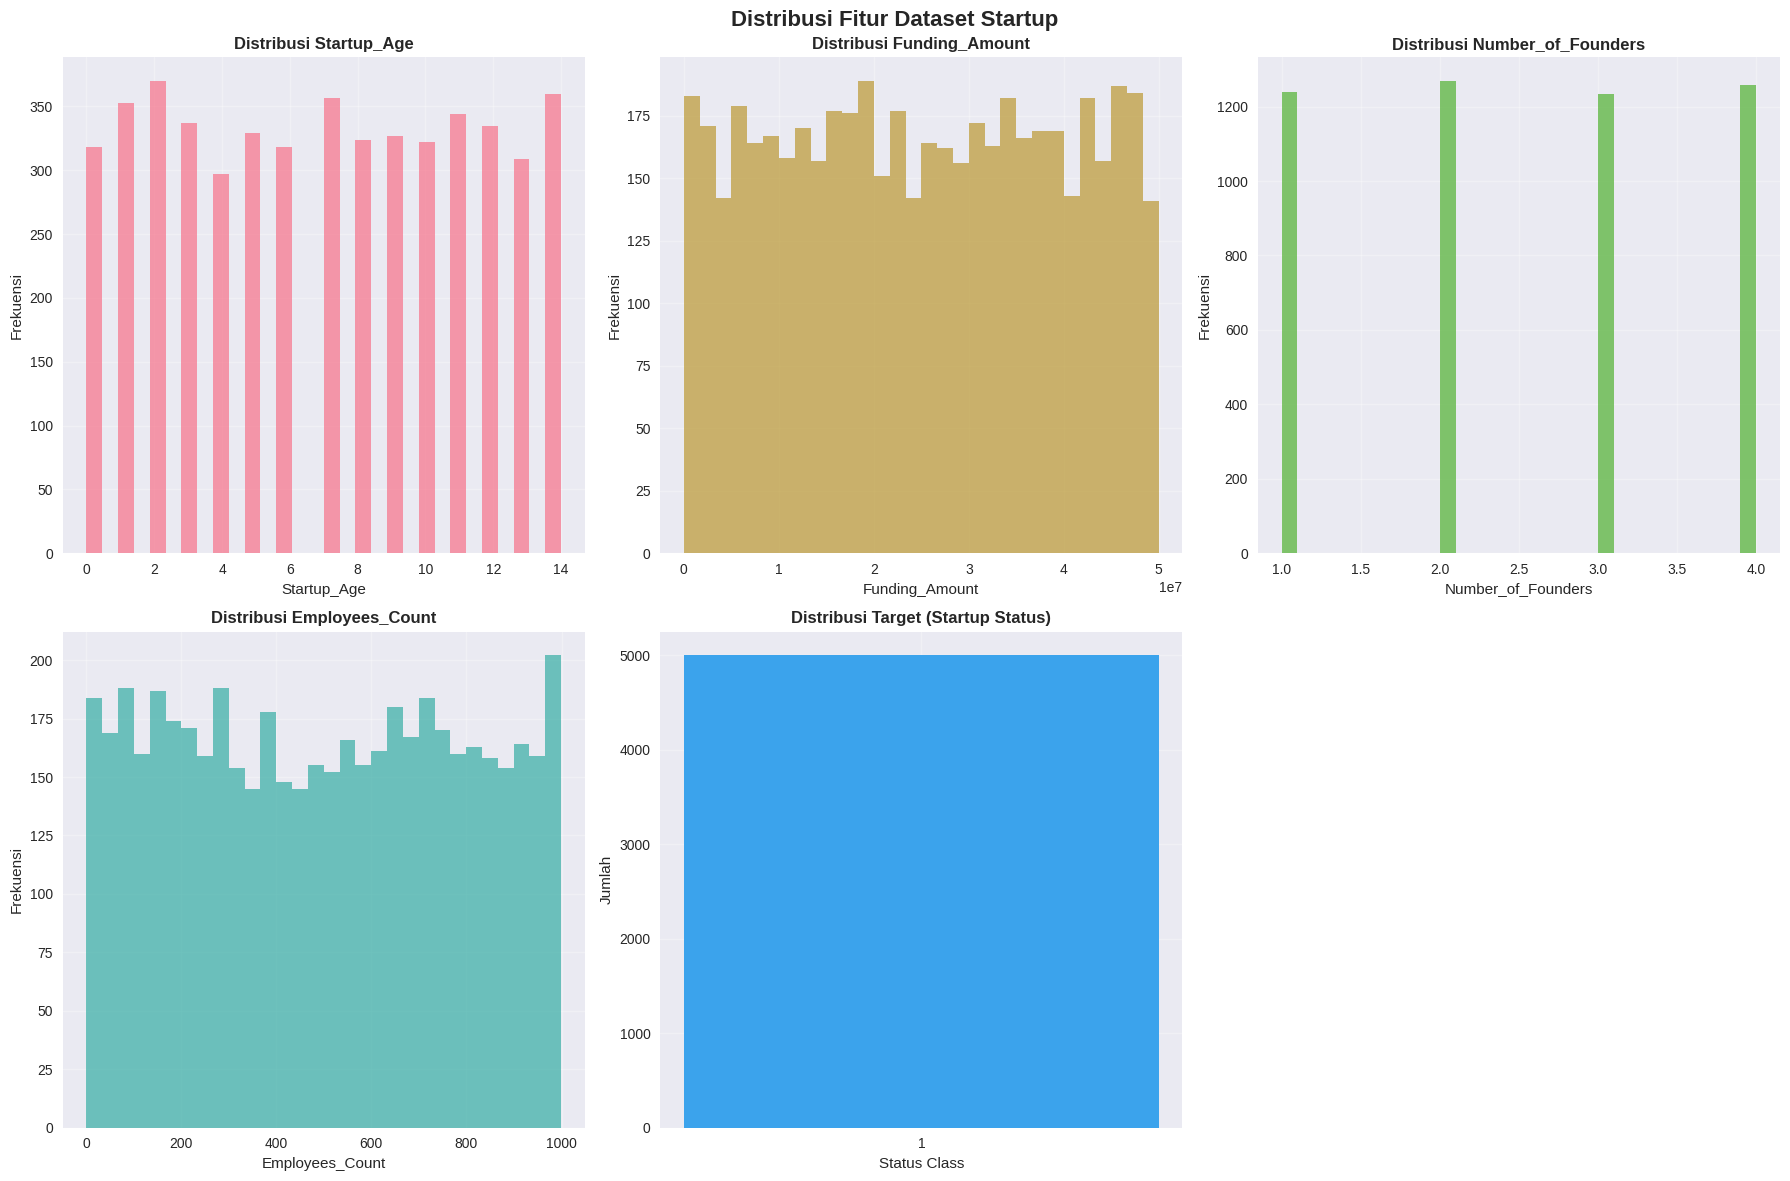

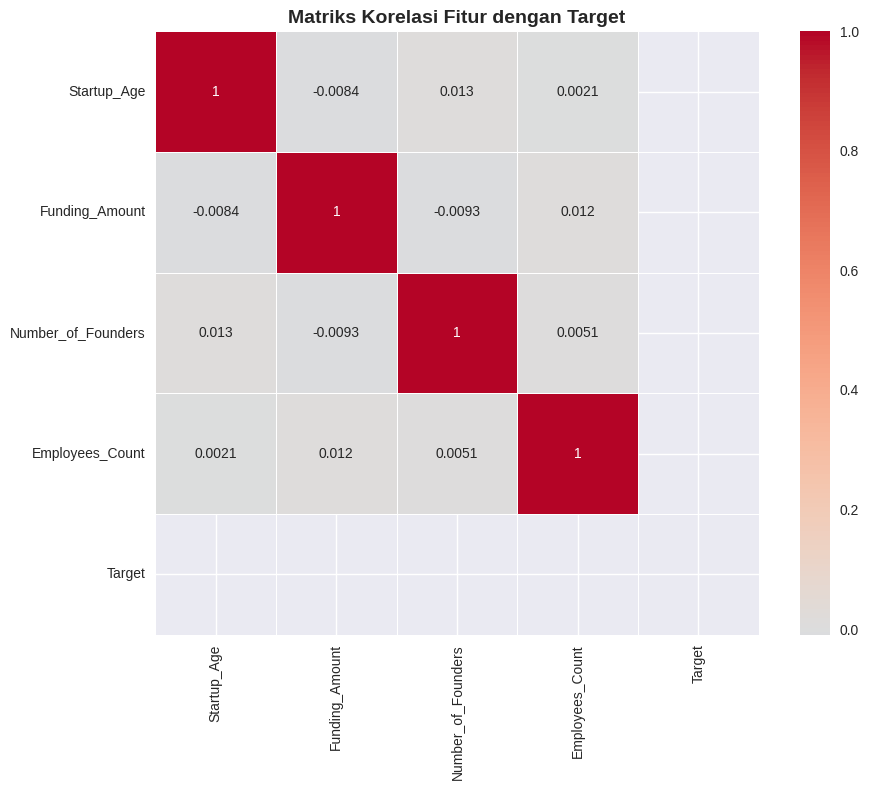


🔧 Setting up sistem fuzzy...
🔹 Setting up Mamdani system...
🔹 Setting up Sugeno system...
✅ Fuzzy systems setup completed!

🔍 Evaluating fuzzy systems...
🔹 Predicting with Mamdani system...
🔹 Predicting with Sugeno system...

📊 HASIL EVALUASI:
Akurasi Mamdani: 0.0000 (0.00%)
Akurasi Sugeno:  1.0000 (100.00%)


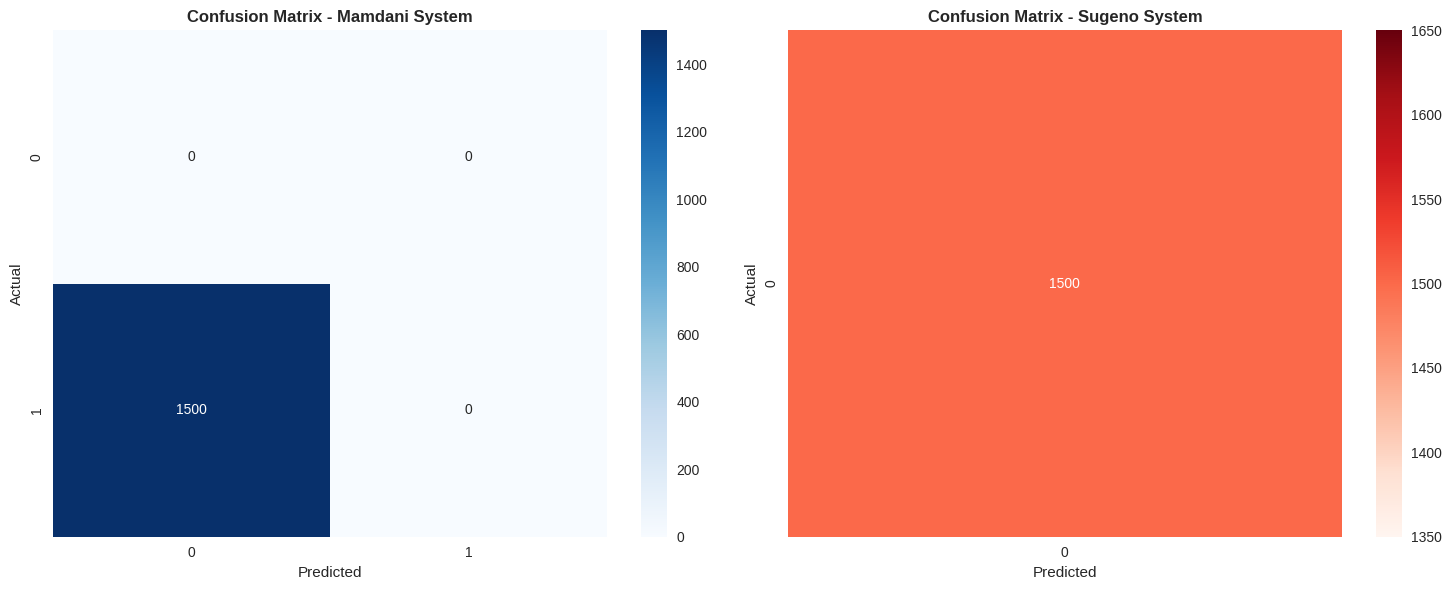


🔍 Analyzing feature importance...

📊 ANALISIS PENTINGNYA FITUR
Korelasi fitur dengan Startup_Status (diurutkan):
  Startup_Age: nan
  Funding_Amount: nan
  Number_of_Founders: nan
  Employees_Count: nan


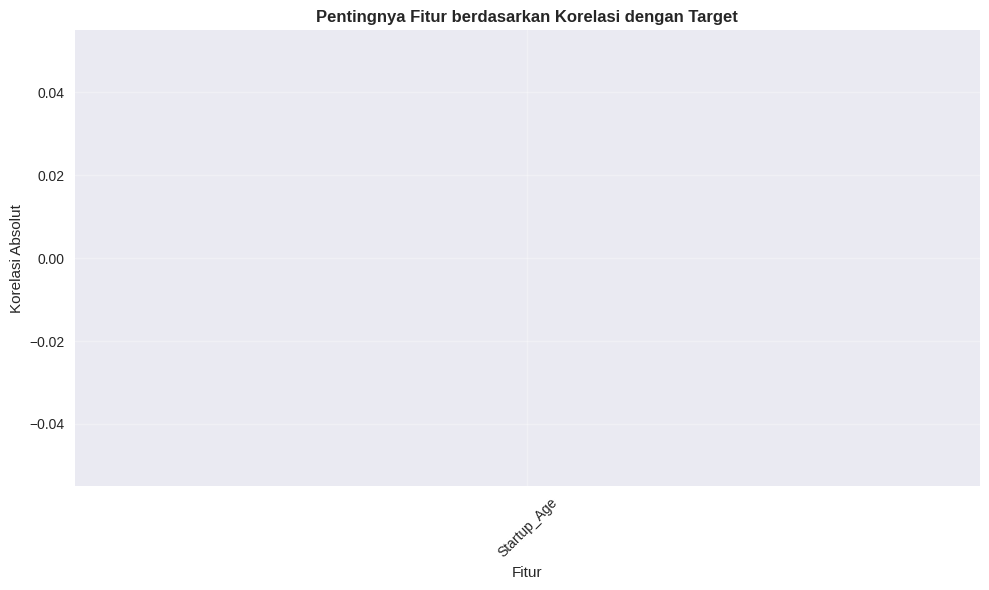


KESIMPULAN
1. Akurasi Sistem Mamdani: 0.0000 (0.00%)
2. Akurasi Sistem Sugeno:  1.0000 (100.00%)
3. Sistem Sugeno menunjukkan performa yang lebih baik
4. Fitur paling penting: Startup_Age (korelasi: nan)
5. Fitur paling lemah: Employees_Count (korelasi: nan)

✅ Analisis selesai!


In [5]:

def main():
    """Fungsi utama untuk menjalankan analisis"""
    print("🚀 SISTEM PREDIKSI STARTUP FAILURE - FUZZY MAMDANI VS SUGENO")
    print("="*70)
    
    # Initialize predictor
    predictor = FuzzyStartupPredictor()
    
    # Load data (ganti dengan path file Anda)
    file_path = "startup_failure_prediction.csv"  # Sesuaikan dengan nama file Anda
    
    try:
        # Load and preprocess data
        df = predictor.load_and_preprocess_data(file_path)
        
        # Visualize data distribution
        predictor.visualize_data_distribution()
        
        # Setup fuzzy systems
        predictor.setup_fuzzy_systems()
        
        # Evaluate systems
        mamdani_acc, sugeno_acc, mamdani_pred, sugeno_pred = predictor.evaluate_systems()
        
        # Analyze feature importance
        feature_importance = predictor.analyze_feature_importance()
        
        # Generate conclusion
        predictor.generate_conclusion(mamdani_acc, sugeno_acc, feature_importance)
        
        print("\n✅ Analisis selesai!")
        
    except FileNotFoundError:
        print(f"❌ File {file_path} tidak ditemukan!")
        print("💡 Pastikan file CSV sudah didownload dari Kaggle dan path sudah benar.")
        print("🔗 Dataset: https://www.kaggle.com/datasets/sakharebharat/startup-failure-prediction-dataset")
    except Exception as e:
        print(f"❌ Error: {str(e)}")

if __name__ == "__main__":
    main()